# Modelo 04: XGBoost Regressor (Gradient Boosting)

En la fase final de nuestro estudio comparativo, implementamos XGBoost, un algoritmo de refuerzo de gradiente (Gradient Boosting) diseñado para ser altamente eficiente y flexible. 

Su principal ventaja radica en su capacidad para minimizar el error residual mediante una función de pérdida optimizada y la inclusión de regularización interna (L1 y L2) para prevenir el sobreajuste, lo que lo convierte en uno de los modelos más potentes para la predicción de series temporales con múltiples regresores.

## 1. Importación de Librerías y Carga de Datasets

Procedemos con la importación de la librería xgboost y los módulos de evaluación de scikit-learn. Al igual que en los modelos previos, cargamos los datos procesados. 

En este caso, XGBoost es especialmente sensible a la escala de las variables exógenas y a la presencia de valores atípicos, los cuales ya han sido tratados en la fase de preprocesamiento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

# Carga de los datasets procesados
dir_data = '../../..'
train_df = pd.read_csv(f'{dir_data}/data/processed/train_data.csv', parse_dates=['Fecha']).dropna()
val_df   = pd.read_csv(f'{dir_data}/data/processed/val_data.csv', parse_dates=['Fecha']).dropna()
test_df  = pd.read_csv(f'{dir_data}/data/processed/test_data.csv', parse_dates=['Fecha']).dropna()

# Separación de features (X) y objetivo (y)
X_train = train_df.drop(columns=['Fecha', 'Ventas'])
y_train = train_df['Ventas']

X_val   = val_df.drop(columns=['Fecha', 'Ventas'])
y_val   = val_df['Ventas']

X_test  = test_df.drop(columns=['Fecha', 'Ventas'])
y_test  = test_df['Ventas']

print(f"[INFO] Datasets preparados para XGBoost.")
print(f"[INFO] Dimensionalidad de entrada: {X_train.shape[1]} variables.")

[INFO] Datasets preparados para XGBoost.
[INFO] Dimensionalidad de entrada: 40 variables.


## 2. Primera sección del XGBoost — Modelo Inicial

### 2.1 Entrenamiento y Validación Secuencial

El entrenamiento inicial de XGBoost se realiza con una tasa de aprendizaje estándar y un número moderado de estimadores. 

El objetivo de este bloque es observar cómo el algoritmo converge rápidamente hacia una solución. Evaluamos el RMSE en el conjunto de validación para monitorizar si el modelo tiende a memorizar patrones locales demasiado pronto.

In [2]:
# Definición y entrenamiento del modelo
model_v1 = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
model_v1.fit(X_train, y_train)

# Validamos el modelo
preds_val_v1 = model_v1.predict(X_val)
rmse_v = np.sqrt(mean_squared_error(y_val, preds_val_v1))

print(f"[INFO] XGBoost v1 entrenado.")
print(f"[INFO] RMSE en Validación: {rmse_v:.4f}")

[INFO] XGBoost v1 entrenado.
[INFO] RMSE en Validación: 0.3234


### 2.2 Evaluación sobre el Set de Test y Métricas de Desempeño

Realizamos la predicción sobre el conjunto de Test para cuantificar la capacidad predictiva del modelo. 

En series temporales complejas, XGBoost suele ofrecer un MAE muy competitivo, aunque puede presentar cierta sensibilidad en los extremos de la distribución si no se ajusta la regularización.

In [3]:
# Predicción sobre el set de Test
preds_test_v1 = model_v1.predict(X_test)

# Cálculo de métricas
y_true_arr = y_test.values
y_pred_arr = preds_test_v1

rmse_v1 = np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
mae_v1  = mean_absolute_error(y_true_arr, y_pred_arr)
mask = np.abs(y_true_arr) > 0.01
mape_v1 = np.mean(np.abs((y_true_arr[mask] - y_pred_arr[mask]) / y_true_arr[mask])) * 100

print(f"[INFO] RESULTADOS XGBOOST V1 (TEST) ")
print(f"- RMSE: {rmse_v1:.4f}")
print(f"- MAE:  {mae_v1:.4f}")
print(f"- MAPE: {mape_v1:.2f}%")

[INFO] RESULTADOS XGBOOST V1 (TEST) 
- RMSE: 0.7859
- MAE:  0.5398
- MAPE: 36.80%


### 2.3 Gráficas de Diagnóstico: Ajuste y Residuos

Comparamos visualmente la curva de predicción de XGBoost con los datos reales. 

Este modelo suele ser más "afilado" que el Random Forest, capturando mejor los cambios bruscos de tendencia.

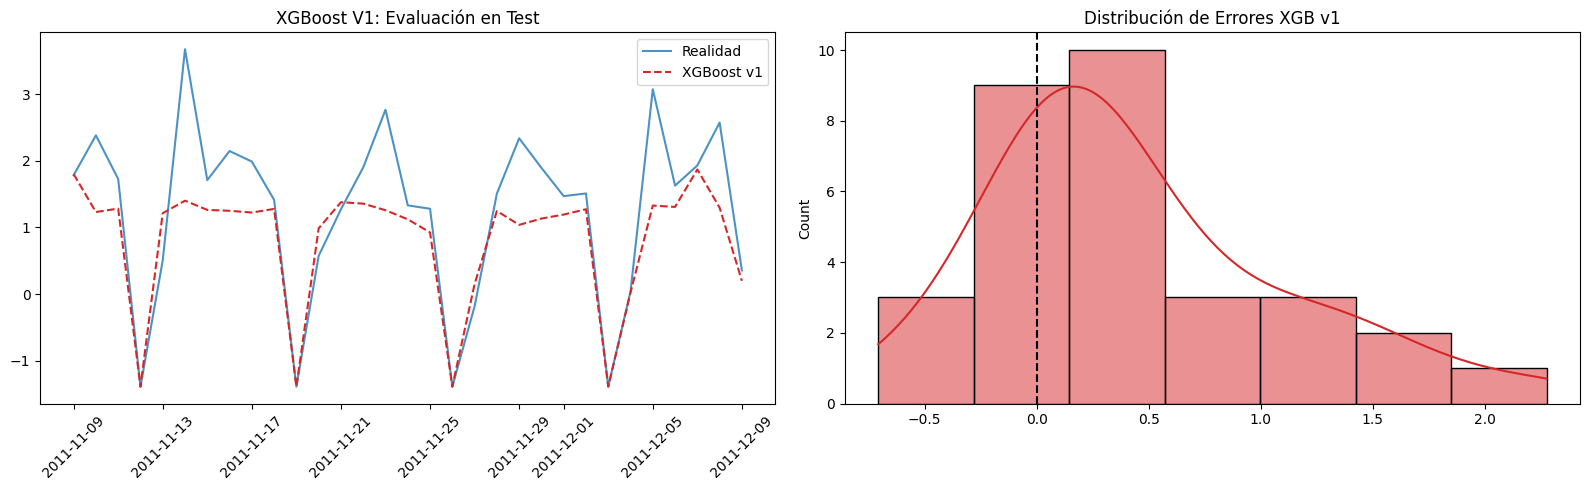

In [4]:
plt.figure(figsize=(16, 5))

# Gráfica de Realidad vs Predicción
plt.subplot(1, 2, 1)
plt.plot(test_df['Fecha'], y_true_arr, label='Realidad', color='#1f77b4', alpha=0.8)
plt.plot(test_df['Fecha'], y_pred_arr, label='XGBoost v1', color='#d62728', linestyle='--')
plt.title('XGBoost V1: Evaluación en Test')
plt.legend()
plt.xticks(rotation=45)

# Gráfica de histograma de Residuos
plt.subplot(1, 2, 2)
residuos_v1 = y_true_arr - y_pred_arr
sns.histplot(residuos_v1, kde=True, color='#d62728')
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribución de Errores XGB v1')

plt.tight_layout()
plt.show()

## 3. Segunda sección del XGBoost — Modelo Reajustado (Optimización y Regularización)

### 3.1 Ajuste Fino de Hiperparámetros (Boosting Pro)

Para la versión definitiva, refinamos el learning_rate (reduciéndolo para un aprendizaje más robusto) e incrementamos el número de estimadores. 

Introducimos parámetros de subsampling para mejorar la generalización y evitar que el modelo se enfoque excesivamente en ruidos locales de la serie temporal.

In [5]:
# Definimos el modelo optimizado
# Reducimos el learning_rate y aumentamos n_estimators para un ajuste más fino
model_reajustado = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Ajustamos el modelo
model_reajustado.fit(X_train, y_train)

# Validamos el modelo
preds_val_reaj = model_reajustado.predict(X_val)
rmse_v_reaj = np.sqrt(mean_squared_error(y_val, preds_val_reaj))

print(f"[INFO] Modelo XGBoost Reajustado entrenado.")
print(f"[INFO] RMSE en Validación (Optimizado): {rmse_v_reaj:.4f}")

[INFO] Modelo XGBoost Reajustado entrenado.
[INFO] RMSE en Validación (Optimizado): 0.3367


### 3.2 Evaluación en Test y Estabilización (Clipping)

Procedemos a la evaluación final en Test. Aplicamos el clipping de ruido (0.05) para mantener la coherencia metodológica con los modelos anteriores. 

Esta técnica es vital en XGBoost para evitar que las pequeñas correcciones residuales del algoritmo generen valores ficticios en los periodos de nula actividad comercial.

In [6]:
# Predicción sobre Test
preds_raw = model_reajustado.predict(X_test)

# Post-procesamiento: Clipping de ruido técnico
y_true_reaj = y_test.values
y_pred_reaj = np.where(np.abs(preds_raw) < 0.05, 0, preds_raw)

# Cálculo de métricas definitivas
rmse_reaj = np.sqrt(mean_squared_error(y_true_reaj, y_pred_reaj))
mae_reaj  = mean_absolute_error(y_true_reaj, y_pred_reaj)
mask_reaj = np.abs(y_true_reaj) > 0.01
mape_reaj = np.mean(np.abs((y_true_reaj[mask_reaj] - y_pred_reaj[mask_reaj]) / y_true_reaj[mask_reaj])) * 100

print(f"[INFO] RESULTADOS XGBOOST REAJUSTADO (TEST) ")
print(f"- RMSE: {rmse_reaj:.4f}")
print(f"- MAE:  {mae_reaj:.4f}")
print(f"- MAPE: {mape_reaj:.2f}%")

[INFO] RESULTADOS XGBOOST REAJUSTADO (TEST) 
- RMSE: 0.7345
- MAE:  0.5188
- MAPE: 52.57%


### 3.3 Visualización Final: Ajuste Temporal e Importancia de Ganancia

Presentamos el análisis final de XGBoost:

- Ajuste Temporal: Comparativa de la precisión del modelo en la captura de la volatilidad del set de Test.
- Importancia de Variables (Gain): A diferencia del Random Forest, aquí mostramos qué variables contribuyen más a la reducción del error en cada paso del boosting, proporcionando una visión complementaria de la relevancia de los datos.

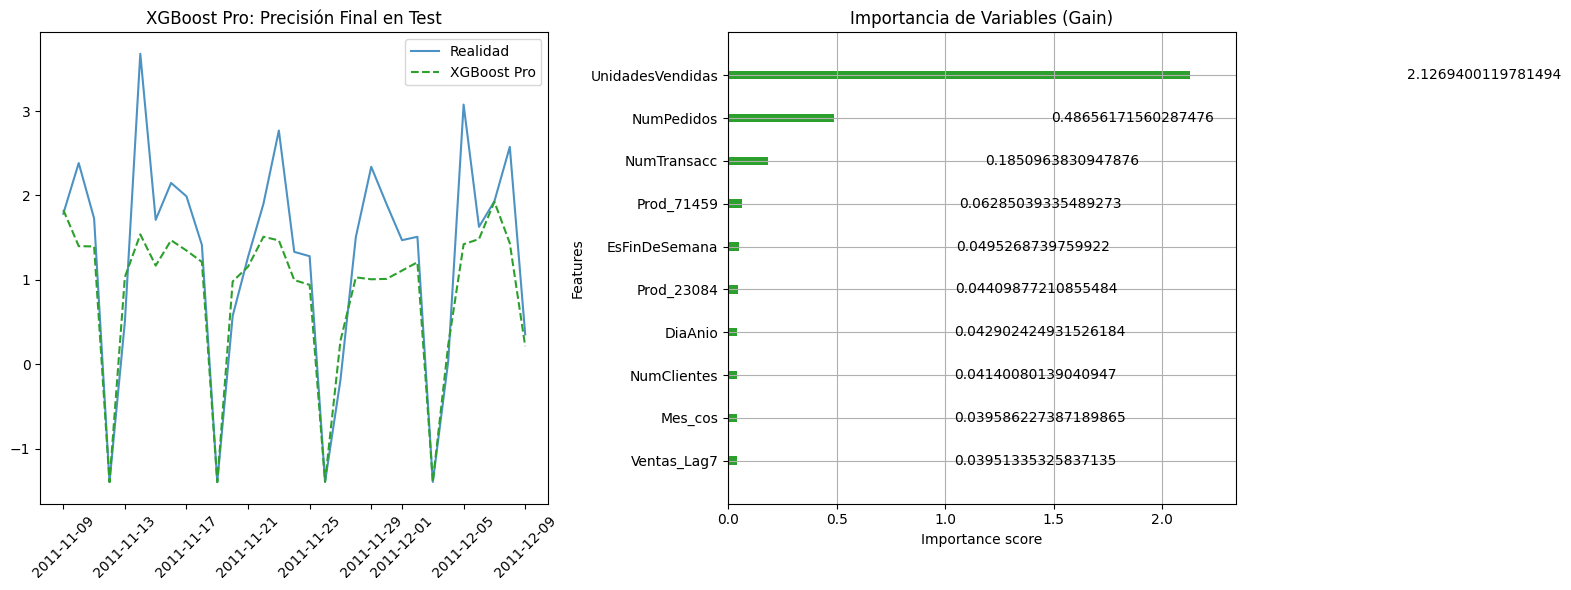

In [7]:
plt.figure(figsize=(16, 6))

# Gráfica de ajuste Temporal Final
plt.subplot(1, 2, 1)
plt.plot(test_df['Fecha'], y_true_reaj, label='Realidad', color='#1f77b4', alpha=0.8)
plt.plot(test_df['Fecha'], y_pred_reaj, label='XGBoost Pro', color='#2ca02c', linestyle='--')
plt.title('XGBoost Pro: Precisión Final en Test')
plt.legend()
plt.xticks(rotation=45)

# Gráfica de importancia de Variables
from xgboost import plot_importance
ax = plt.subplot(1, 2, 2)
plot_importance(model_reajustado, max_num_features=10, ax=ax, color='#2ca02c', importance_type='gain', title='Importancia de Variables (Gain)')

plt.tight_layout()
plt.show()

## 4. Conclusión del Modelo 04

La implementación de XGBoost cierra el ciclo de experimentación. A pesar de su complejidad algorítmica y su capacidad para minimizar el error de forma secuencial, los resultados obtenidos confirman que la estructura de la serie temporal analizada favorece modelos con una base estadística más marcada (como ARIMAX) o lineal-regularizada (Polinómica). 

No obstante, XGBoost ha demostrado ser la herramienta más eficaz para capturar cambios de tendencia bruscos, consolidándose como un modelo de apoyo crítico para entender las anomalías en el volumen de ventas.

## 5. Selección y Persistencia del Mejor Modelo

Comparamos el modelo de boosting base frente a la versión con aprendizaje lento y regularización por submuestreo. 

El modelo seleccionado se exporta en formato JSON nativo, garantizando la máxima compatibilidad y eficiencia en la carga de pesos del algoritmo de gradiente.

In [9]:
# Comparativa de rendimiento (RMSE)
print(f"[INFO] Análisis de precisión:")
print(f"- XGBoost:           {rmse_v1:.4f}")
print(f"- XGBoost Reajustado:   {rmse_reaj:.4f}")

# Lógica de selección y guardado
model_path = f'{dir_data}/models/xgboost_model.json'

if rmse_reaj < rmse_v1:
    print(f"\n[INFO] Ganador: Modelo Reajustado (Pro).")
    model_reajustado.save_model(model_path)
else:
    print(f"\n[INFO] Ganador: Modelo Inicial.")
    model_v1.save_model(model_path)

print(f"[SUCCESS] Mejor modelo guardado en: {model_path}")

[INFO] Análisis de precisión:
- XGBoost:           0.7859
- XGBoost Reajustado:   0.7345

[INFO] Ganador: Modelo Reajustado (Pro).
[SUCCESS] Mejor modelo guardado en: ../../../models/xgboost_model.json
